In [37]:
# Install required packages
!pip install torch torchvision torchaudio
!pip install causal-conv1d==1.4.0
!pip install mamba-ssm
# If you plan to use stable baselines for any boilerplate:
!pip install stable-baselines3[extra]
# =====================================================================
# 1. SYSTEM PACKAGE INSTALLATIONS
# =====================================================================
# Installs all required trading and reinforcement learning binaries quietly
!pip install -q yfinance ta stable-baselines3[extra]

# =====================================================================
# 2. CORE MATHEMATICS, DATA SCIENCE & TECHNICAL ANALYSIS
# =====================================================================
import os
import sys
import math
import random
import time
from datetime import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import ta
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 3. PYTORCH DEEP LEARNING FRAMEWORK
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical  # <--- FIXED: Explicitly added for action sampling!

# Lock down hardware acceleration diagnostics (T4 GPU active check)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility seed for this complete run
SEED = 45
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"System Matrix Core Processing Unit initialized on: {device}")

# =====================================================================
# 4. STABLE-BASELINES3 & REINFORCEMENT LEARNING UTILITIES
# =====================================================================
import stable_baselines3
from stable_baselines3 import PPO, A2C, DDPG, SAC
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

# =====================================================================
# 5. PLOTTING, VISUALIZATIONS & GRAPHICS CONFIGURATION
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Configure global visualization canvas defaults for professional outputs
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

print("Global initialization complete. All upstream frameworks registered successfully.")

  Using cached causal_conv1d-1.4.0.tar.gz (9.3 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Using cached mamba_ssm-2.3.2.post1.tar.gz (216 kB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did n

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training+Validation+Testing splits

In [26]:
!pip install yfinance
!pip install ta

import yfinance as yf
import pandas as pd
import ta
import numpy as np
from sklearn.preprocessing import StandardScaler

# Download 5 years of daily Bitcoin data
ticker = "BTC-USD"
df = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# FIX: Flatten MultiIndex columns if yfinance returned them grouped by ticker
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Forward-fill only from information already available; never backfill from future rows
df = df.ffill().dropna()

# Extract clean 1D Series for the technical analysis library
close_series = df['Close'].squeeze()
high_series = df['High'].squeeze()
low_series = df['Low'].squeeze()
volume_series = df['Volume'].squeeze()

# Calculate returns cleanly as a 1D Series
returns_series = close_series.pct_change()

# Build the complete feature matrix based on the table
df_features = pd.DataFrame(index=df.index)

# 1. Base Stationary Returns
df_features['Returns'] = returns_series

# 2. Momentum Indicators
df_features['RSI'] = ta.momentum.rsi(close_series, window=14)
df_features['MACD_Diff'] = ta.trend.macd_diff(close_series)

# 3. Volatility Indicators (Direction-Blind & Direction-Specific)
df_features['BB_Width'] = ta.volatility.bollinger_wband(close_series)
df_features['ATR'] = ta.volatility.average_true_range(high_series, low_series, close_series)

# NEW: Separate Bullish and Bearish Volatility Channels
ret_positive = returns_series.clip(lower=0)
ret_negative = returns_series.clip(upper=0).abs()
df_features['Bullish_Vol'] = ret_positive.rolling(window=14).std()
df_features['Bearish_Vol'] = ret_negative.rolling(window=14).std()

# 4. Volume Dynamics
df_features['Log_Volume_Chg'] = np.log1p(volume_series).diff()

# 5. Price Channels (Normalized location between 0 and 1)
donchian_high = ta.volatility.donchian_channel_hband(high_series, low_series, close_series, window=14)
donchian_low = ta.volatility.donchian_channel_lband(high_series, low_series, close_series, window=14)
df_features['Donchian_Pos'] = (close_series - donchian_low) / (donchian_high - donchian_low + 1e-8)

# Clean up initial NaN rows caused by lagging indicators (like the 14-day window)
df_features = df_features.dropna()

# Extract raw numpy feature matrix before splitting
raw_features_matrix = df_features.values
total_timesteps = len(raw_features_matrix)

# =====================================================================
# CHRONOLOGICAL THREE-WAY SPLIT LOGIC (70% Train, 15% Val, 15% Test)
# =====================================================================
val_size = int(total_timesteps * 0.15)
test_size = int(total_timesteps * 0.15)
train_size = total_timesteps - (val_size + test_size)

# Slice features chronologically
X_train_raw = raw_features_matrix[:train_size]
X_val_raw   = raw_features_matrix[train_size : train_size + val_size]
X_test_raw  = raw_features_matrix[train_size + val_size:]

# Slice matching close prices for backtesting calculations down the line
close_prices_array = close_series.reindex(df_features.index).to_numpy()  # Exact date alignment; no positional look-ahead
close_train = close_prices_array[:train_size]
close_val   = close_prices_array[train_size : train_size + val_size]
close_test  = close_prices_array[train_size + val_size:]

# =====================================================================
# HONEST SCALING (Zero Look-Ahead Bias / No Leakage)
# =====================================================================
scaler = StandardScaler()

# Fit ONLY on training history parameters
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform validation and testing matrices using purely historical training bounds
X_val_scaled  = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Total processed dataset steps: {total_timesteps}")
print(f"-> Train Section Matrix : {X_train_scaled.shape} | Prices: {len(close_train)}")
print(f"-> Val Section Matrix   : {X_val_scaled.shape} | Prices: {len(close_val)}")
print(f"-> Test Section Matrix  : {X_test_scaled.shape} | Prices: {len(close_test)}")
print("\nFeatures compiled and split academically with zero look-ahead leakage!")

/tmp/ipykernel_565/702140908.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Total processed dataset steps: 1793
-> Train Section Matrix : (1257, 9) | Prices: 1257
-> Val Section Matrix   : (268, 9) | Prices: 268
-> Test Section Matrix  : (268, 9) | Prices: 268

Features compiled and split academically with zero look-ahead leakage!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
!pip install yfinance
!pip install ta

import yfinance as yf
import pandas as pd
import ta
import numpy as np
from sklearn.preprocessing import StandardScaler

# Download 5 years of daily Bitcoin data
ticker = "BTC-USD"
df = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# FIX: Flatten MultiIndex columns if yfinance returned them grouped by ticker
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Forward-fill only from information already available; never backfill from future rows
df = df.ffill().dropna()

# Extract clean 1D Series for the technical analysis library
close_series = df['Close'].squeeze()
high_series = df['High'].squeeze()
low_series = df['Low'].squeeze()
volume_series = df['Volume'].squeeze()

# Calculate returns cleanly as a 1D Series
returns_series = close_series.pct_change()

# Build the complete feature matrix based on the table
df_features = pd.DataFrame(index=df.index)

# 1. Base Stationary Returns
df_features['Returns'] = returns_series

# 2. Momentum Indicators
df_features['RSI'] = ta.momentum.rsi(close_series, window=14)
df_features['MACD_Diff'] = ta.trend.macd_diff(close_series)

# 3. Volatility Indicators (Direction-Blind & Direction-Specific)
df_features['BB_Width'] = ta.volatility.bollinger_wband(close_series)
df_features['ATR'] = ta.volatility.average_true_range(high_series, low_series, close_series)

# NEW: Separate Bullish and Bearish Volatility Channels
ret_positive = returns_series.clip(lower=0)
ret_negative = returns_series.clip(upper=0).abs()
df_features['Bullish_Vol'] = ret_positive.rolling(window=14).std()
df_features['Bearish_Vol'] = ret_negative.rolling(window=14).std()

# 4. Volume Dynamics
df_features['Log_Volume_Chg'] = np.log1p(volume_series).diff()

# 5. Price Channels (Normalized location between 0 and 1)
donchian_high = ta.volatility.donchian_channel_hband(high_series, low_series, close_series, window=14)
donchian_low = ta.volatility.donchian_channel_lband(high_series, low_series, close_series, window=14)
df_features['Donchian_Pos'] = (close_series - donchian_low) / (donchian_high - donchian_low + 1e-8)

# Clean up initial NaN rows caused by lagging indicators (like the 14-day window)
df_features = df_features.dropna()

# Extract raw numpy feature matrix before splitting
raw_features_matrix = df_features.values
total_timesteps = len(raw_features_matrix)

# =====================================================================
# CHRONOLOGICAL THREE-WAY SPLIT LOGIC (70% Train, 15% Val, 15% Test)
# =====================================================================
val_size = int(total_timesteps * 0.15)
test_size = int(total_timesteps * 0.15)
train_size = total_timesteps - (val_size + test_size)

# Slice features chronologically
X_train_raw = raw_features_matrix[:train_size]
X_val_raw   = raw_features_matrix[train_size : train_size + val_size]
X_test_raw  = raw_features_matrix[train_size + val_size:]

# Slice matching close prices for backtesting calculations down the line
close_prices_array = close_series.reindex(df_features.index).to_numpy()  # Exact date alignment; no positional look-ahead
close_train = close_prices_array[:train_size]
close_val   = close_prices_array[train_size : train_size + val_size]
close_test  = close_prices_array[train_size + val_size:]

# =====================================================================
# HONEST SCALING (Zero Look-Ahead Bias / No Leakage)
# =====================================================================
scaler = StandardScaler()

# Fit ONLY on training history parameters
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform validation and testing matrices using purely historical training bounds
X_val_scaled  = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Total processed dataset steps: {total_timesteps}")
print(f"-> Train Section Matrix : {X_train_scaled.shape} | Prices: {len(close_train)}")
print(f"-> Val Section Matrix   : {X_val_scaled.shape} | Prices: {len(close_val)}")
print(f"-> Test Section Matrix  : {X_test_scaled.shape} | Prices: {len(close_test)}")
print("\nFeatures compiled and split academically with zero look-ahead leakage!")

/tmp/ipykernel_565/702140908.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Total processed dataset steps: 1793
-> Train Section Matrix : (1257, 9) | Prices: 1257
-> Val Section Matrix   : (268, 9) | Prices: 268
-> Test Section Matrix  : (268, 9) | Prices: 268

Features compiled and split academically with zero look-ahead leakage!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
# Map your scaled training matrix back to a DataFrame for easy viewing
df_scaled_view = pd.DataFrame(X_train_scaled, index=df_features.index[:len(X_train_scaled)], columns=df_features.columns)

# Display the first 10 rows of your complete feature matrix
df_scaled_view.head(10)

,Returns,RSI,MACD_Diff,BB_Width,ATR,Bullish_Vol,Bearish_Vol,Log_Volume_Chg,Donchian_Pos
Date,,,,,,,,,
2021-02-03,1.685519,0.658357,0.862261,0.246292,1.342981,1.629361,2.321245,-0.089599,1.260100
2021-02-04,-0.480904,0.514943,1.023263,0.252534,1.283682,1.629361,0.338666,0.357227,1.011088
2021-02-05,0.994963,0.734334,1.246642,0.379902,1.178939,1.335308,0.338666,-0.479581,1.429208
2021-02-06,0.883735,0.922879,1.480635,0.599827,1.161794,1.270337,0.278883,0.592221,1.129388
2021-02-07,-0.315274,0.816149,1.490985,0.734460,1.108486,1.309330,0.263151,-0.252241,1.023149
2021-02-08,5.788243,1.722410,2.464550,1.663615,1.476901,3.792460,0.263151,1.314867,1.591018
2021-02-09,0.162437,1.747640,2.971530,2.321905,1.447503,3.793065,0.263151,-0.296642,1.317698
2021-02-10,-1.072128,1.333928,2.885514,2.514901,1.450232,3.793065,-0.440972,-0.147808,1.015292
2021-02-11,2.037554,1.632339,3.084480,2.928338,1.523775,3.530073,-0.440972,-0.207052,1.478847


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class MarketWindowDataset(Dataset):
    def __init__(self, data, window_size=14):
        # Handle conversion cleanly if it's already a tensor or numpy array
        if isinstance(data, torch.Tensor):
            self.data = data.clone().detach().float()
        else:
            self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size + 1

    def __getitem__(self, idx):
        # Slice out a historical window matrix
        window = self.data[idx : idx + self.window_size]
        # Transpose from (Window_Length, Features) to (Features, Window_Length) for Conv1D
        return window.t()

# Standard lookback setup
window_size = 14

# =====================================================================
# INDEPENDENT PYTORCH DATASETS (Separated Timelines)
# =====================================================================
train_dataset = MarketWindowDataset(X_train_scaled, window_size=window_size)
val_dataset   = MarketWindowDataset(X_val_scaled, window_size=window_size)
test_dataset  = MarketWindowDataset(X_test_scaled, window_size=window_size)

# =====================================================================
# INDEPENDENT DATA LOADERS (ALL shuffle=False)
# =====================================================================
# The DRN is used as a STATIC feature extractor only — its weights are never updated.
# Shuffling the train loader would scramble the row order of rl_train_features,
# breaking the timestep alignment between features and close_train prices in the RL env.
# All three loaders must be chronologically ordered.
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f">>> PyTorch Data Pipelines Instantiated Successfully! <<<")
print(f"-> Train Windows (Batches) : {len(train_dataset)} segments ({len(train_dataloader)} batches)")
print(f"-> Val Windows (Batches)   : {len(val_dataset)} segments ({len(val_dataloader)} batches)")
print(f"-> Test Windows (Batches)  : {len(test_dataset)} segments ({len(test_dataloader)} batches)")

>>> PyTorch Data Pipelines Instantiated Successfully! <<<
-> Train Windows (Batches) : 1244 segments (39 batches)
-> Val Windows (Batches)   : 255 segments (8 batches)
-> Test Windows (Batches)  : 255 segments (8 batches)


In [30]:
import torch
import torch.nn as nn

class FinancialResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(FinancialResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Identity shortcut: matches dimensions if number of features shifts
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)  # Identity path preserves sharp raw features
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual              # F(x) + x: Blends raw shapes with abstract concepts
        return self.relu(out)

class PriceFeatureDRN(nn.Module):
    def __init__(self, input_features=9, embedding_dim=32):  # FIX: Set input_features to 9 for the new columns
        super(PriceFeatureDRN, self).__init__()
        self.initial_conv = nn.Conv1d(input_features, 16, kernel_size=3, padding=1)
        self.layer1 = FinancialResidualBlock(16, 16)
        self.layer2 = FinancialResidualBlock(16, embedding_dim)
        self.pool = nn.AdaptiveAvgPool1d(1)  # Flattens time dimension out cleanly

    def forward(self, x):
        out = self.initial_conv(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.pool(out)
        return out.squeeze(-1)  # Returns shape: (Batch, embedding_dim)

# Move model to your active T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drn_extractor = PriceFeatureDRN(input_features=9, embedding_dim=32).to(device)
drn_extractor.eval()  # Set to evaluation mode since we are generating static states

# Helper function to generate clean DRN latent embeddings per section dataset
def extract_latent_features(dataloader_target):
    section_states = []
    with torch.no_grad():
        for batch in dataloader_target:
            batch = batch.to(device)
            embeddings = drn_extractor(batch)
            section_states.append(embeddings.cpu())
    return torch.cat(section_states, dim=0).numpy()

# =====================================================================
# INDEPENDENT STATE GENERATION (Three Non-Overlapping Timelines)
# =====================================================================
print("Processing separated timelines through the DRN feature extractor...")

rl_train_features = extract_latent_features(train_dataloader)
rl_val_features   = extract_latent_features(val_dataloader)
rl_test_features  = extract_latent_features(test_dataloader)

# =====================================================================
# LEAKAGE-SAFE PRICE ALIGNMENT FOR THE UNIFIED MODEL
# =====================================================================
# Window i contains rows [i, ..., i + window_size - 1]. The corresponding
# decision is therefore made at the final row of that window, not its first row.
# Trimming the first window_size - 1 prices prevents the DRN from seeing future
# observations relative to the return used by the trading environment.
unified_close_train = np.asarray(close_train)[window_size - 1:]
unified_close_val   = np.asarray(close_val)[window_size - 1:]
unified_close_test  = np.asarray(close_test)[window_size - 1:]

assert len(rl_train_features) == len(unified_close_train)
assert len(rl_val_features)   == len(unified_close_val)
assert len(rl_test_features)  == len(unified_close_test)

print("\n>>> DRN State Generation Complete for All Sections! <<<")
print(f"-> Train RL State Shape : {rl_train_features.shape} (Optimizing Policies)")
print(f"-> Val RL State Shape   : {rl_val_features.shape} (Checkpoint Gating)")
print(f"-> Test RL State Shape  : {rl_test_features.shape} (Pure Out-Of-Sample Backtest)")

Processing separated timelines through the DRN feature extractor...

>>> DRN State Generation Complete for All Sections! <<<
-> Train RL State Shape : (1244, 32) (Optimizing Policies)
-> Val RL State Shape   : (255, 32) (Checkpoint Gating)
-> Test RL State Shape  : (255, 32) (Pure Out-Of-Sample Backtest)


Reinforcement Learning

In [31]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class MultiObjectiveTradingEnv(gym.Env):
    def __init__(self, drn_features, raw_close_prices, transaction_fee=0.0005):
        super(MultiObjectiveTradingEnv, self).__init__()

        # Ingest pre-compiled 32-dimensional latent representations directly
        self.raw_features = drn_features

        # Safely align and clear pandas indexing if needed
        if isinstance(raw_close_prices, (pd.Series, pd.DataFrame)):
            self.close_prices = raw_close_prices.reset_index(drop=True).values
        else:
            self.close_prices = np.array(raw_close_prices)

        self.transaction_fee = transaction_fee

        self.current_step = 0
        self.max_steps = len(self.raw_features) - 1

        # Track past position to enforce transaction fee friction costs
        self.last_action = 1  # Start out in cash/flat

        # EXPANDED ACTION SPACE: 0 = Short, 1 = Cash/Flat, 2 = Long
        self.action_space = spaces.Discrete(3)

        # Updated observation dimensions matching the 32 DRN latent features
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(32,), dtype=np.float32)

        # Multi-Objective Preference Vectors
        self.w_profit = 0.5
        self.w_drawdown = 0.5

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.last_action = 1  # Reset position back to cash/flat

        # Randomize balance vectors at the start of every sequence
        self.w_profit = np.random.uniform(0.0, 1.0)
        self.w_drawdown = 1.0 - self.w_profit

        return self._get_observation(), {}

    def _get_observation(self):
        # Extract the single 32-dimensional feature vector for step t
        return self.raw_features[self.current_step].astype(np.float32)

    def step(self, action):
        current_price = self.close_prices[self.current_step]
        next_price = self.close_prices[self.current_step + 1]
        price_return = (next_price - current_price) / current_price

        # Determine current directional position exposureMultiplier
        # Action mapping: 0 -> -1 (Short), 1 -> 0 (Flat), 2 -> 1 (Long)
        position_multiplier = action - 1

        # Calculate directional profit return
        r_profit = position_multiplier * price_return

        # Apply downside risk tracking (Penalizes any position experiencing negative returns)
        r_drawdown = r_profit if r_profit < 0 else 0.0

        # Charge fees in proportion to position turnover:
        # flat <-> long/short costs one fee; long <-> short costs two fees.
        turnover = abs(int(action) - int(self.last_action))
        r_profit -= self.transaction_fee * turnover

        # Store current exposure selection for the next tracking round
        self.last_action = action

        # Blended scalarization using current preference conditions
        total_reward = (self.w_profit * r_profit) + (self.w_drawdown * r_drawdown)

        self.current_step += 1
        terminated = self.current_step >= self.max_steps

        return self._get_observation(), float(total_reward), terminated, False, {}

# =====================================================================
# INDEPENDENT ENVIRONMENT INSTANTIATION
# =====================================================================
# Instantiate individual environments for each separate split section
train_env = MultiObjectiveTradingEnv(rl_train_features, unified_close_train)
val_env   = MultiObjectiveTradingEnv(rl_val_features, unified_close_val)
test_env  = MultiObjectiveTradingEnv(rl_test_features, unified_close_test)

print("All academic Train, Val, and Test environments configured and registered successfully!")

All academic Train, Val, and Test environments configured and registered successfully!


In [32]:
# =====================================================================
# 1. ACADEMIC COMPLIANT AGENT MODEL ARCHITECTURE (PPO POLICY HEADS)
# =====================================================================
class UnifiedMultiObjectivePPO(nn.Module):
    def __init__(self, drn_embedding_dim=32, action_dim=3):
        super(UnifiedMultiObjectivePPO, self).__init__()

        # 32 static latent features from DRN + 2 dynamic preference weights = 34 dimensions
        policy_input_dim = drn_embedding_dim + 2

        # Actor Head (Policy Network)
        self.actor = nn.Sequential(
            nn.Linear(policy_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )

        # Critic Head (Value Network)
        self.critic = nn.Sequential(
            nn.Linear(policy_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, drn_latent_features, preference_weights):
        # Directly stack pre-compiled embeddings alongside preference dimensions
        combined_state = torch.cat([drn_latent_features, preference_weights], dim=-1)

        action_probs = self.actor(combined_state)
        state_value = self.critic(combined_state)

        return action_probs, state_value


# =====================================================================
# 2. TRAINING LOOPS & ACADEMIC CHECKPOINT ENGINE
# =====================================================================
# Hyperparameters
epochs = 500
gamma = 0.99
ppo_epochs = 4
clip_eps = 0.2
lr = 3e-4

# Instantiations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model targets 3 actions: 0=Short, 1=Flat, 2=Long
agent = UnifiedMultiObjectivePPO(drn_embedding_dim=32, action_dim=3).to(device)
optimizer = optim.Adam(agent.parameters(), lr=lr)

best_val_reward = -np.inf

print("Starting Unified Multi-Objective Training Loop across isolated timelines...\n")

for epoch in range(epochs):
    # Train purely inside the training section environment
    state_feature, _ = train_env.reset()
    done = False

    w_p, w_d = train_env.w_profit, train_env.w_drawdown

    memory_states = []
    memory_actions = []
    memory_logprobs = []
    memory_rewards = []
    memory_values = []
    memory_dones = []

    # Trajectory Rollout Collection (In-Sample Training Section)
    while not done:
        state_t = torch.tensor(state_feature, dtype=torch.float32).unsqueeze(0).to(device)
        pref_t = torch.tensor([w_p, w_d], dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            action_probs, state_value = agent(state_t, pref_t)
            dist = Categorical(action_probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

        next_state, reward, terminated, truncated, _ = train_env.step(action.item())
        done = terminated or truncated

        memory_states.append(state_t.squeeze(0))
        memory_actions.append(action)
        memory_logprobs.append(log_prob)
        memory_rewards.append(reward)
        memory_values.append(state_value.squeeze(0))
        memory_dones.append(done)

        state_feature = next_state

    # Process Discounted Rewards
    returns = []
    discounted_reward = 0
    for r, d in zip(reversed(memory_rewards), reversed(memory_dones)):
        if d:
            discounted_reward = 0
        discounted_reward = r + (gamma * discounted_reward)
        returns.insert(0, discounted_reward)

    batch_states = torch.stack(memory_states)
    batch_actions = torch.stack(memory_actions)
    batch_logprobs = torch.stack(memory_logprobs)
    batch_returns = torch.tensor(returns, dtype=torch.float32).to(device)
    batch_values = torch.stack(memory_values).squeeze(-1)
    batch_pref = torch.tensor([w_p, w_d], dtype=torch.float32).repeat(len(memory_rewards), 1).to(device)

    # Policy Gradient Optimization Step
    for _ in range(ppo_epochs):
        action_probs, state_values = agent(batch_states, batch_pref)
        state_values = state_values.squeeze(-1)

        dist = Categorical(action_probs)
        new_logprobs = dist.log_prob(batch_actions)
        entropy = dist.entropy().mean()

        advantages = batch_returns - batch_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        ratios = torch.exp(new_logprobs - batch_logprobs)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * advantages

        actor_loss = -torch.min(surr1, surr2).mean()
        critic_loss = nn.MSELoss()(state_values, batch_returns)
        total_loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    # =====================================================================
    # PERIODIC VALIDATION CHECKPOINT GATE (Every 10 Epochs)
    # =====================================================================
    if (epoch + 1) % 10 == 0 or epoch == 0:
        agent.eval()  # Freeze layers for clean evaluation pass
        val_state, _ = val_env.reset()
        val_done = False
        val_rewards = 0

        # Mirror the active training preferences into validation tracking
        val_env.w_profit, val_env.w_drawdown = w_p, w_d

        while not val_done:
            v_state_t = torch.tensor(val_state, dtype=torch.float32).unsqueeze(0).to(device)
            v_pref_t = torch.tensor([w_p, w_d], dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                v_probs, _ = agent(v_state_t, v_pref_t)
                v_action = torch.argmax(v_probs, dim=-1)  # Take highest probability action

            next_val_state, val_r, val_term, val_trunc, _ = val_env.step(v_action.item())
            val_rewards += val_r
            val_done = val_term or val_trunc
            val_state = next_val_state

        print(f"Epoch {epoch+1:03d}/{epochs:03d} | Prefs -> Profit: {w_p:.2f}, Risk-Aversion: {w_d:.2f} | Train Reward: {sum(memory_rewards):.2f} | Val Section Reward: {val_rewards:.2f}")

        # Save absolute best model configuration based on out-of-sample validation results
        if val_rewards > best_val_reward:
            best_val_reward = val_rewards
            torch.save(agent.state_dict(), "best_agent.pt")
            print("--> Validation breakthrough achieved. Weights saved successfully!")

        agent.train()  # Restore training mode for the next cycle

print("\nUnified Optimization Complete! Best weights locked inside 'best_agent.pt'.")

Starting Unified Multi-Objective Training Loop across isolated timelines...

Epoch 001/1000 | Prefs -> Profit: 0.99, Risk-Aversion: 0.01 | Train Reward: -1.48 | Val Section Reward: -0.28
--> Validation breakthrough achieved. Weights saved successfully!
Epoch 010/1000 | Prefs -> Profit: 0.86, Risk-Aversion: 0.14 | Train Reward: -1.82 | Val Section Reward: -0.62
Epoch 020/1000 | Prefs -> Profit: 0.11, Risk-Aversion: 0.89 | Train Reward: -7.49 | Val Section Reward: -0.98
Epoch 030/1000 | Prefs -> Profit: 0.60, Risk-Aversion: 0.40 | Train Reward: -4.28 | Val Section Reward: -0.96
Epoch 040/1000 | Prefs -> Profit: 0.45, Risk-Aversion: 0.55 | Train Reward: -6.00 | Val Section Reward: -1.21
Epoch 050/1000 | Prefs -> Profit: 0.26, Risk-Aversion: 0.74 | Train Reward: -7.31 | Val Section Reward: -0.87
Epoch 060/1000 | Prefs -> Profit: 0.47, Risk-Aversion: 0.53 | Train Reward: -4.90 | Val Section Reward: -0.45
Epoch 070/1000 | Prefs -> Profit: 0.94, Risk-Aversion: 0.06 | Train Reward: -0.51 | Val

Loading optimized checkpoint 'best_agent.pt' for final testing...
Simulating 20 unique random preference profiles over 254 out-of-sample testing periods...


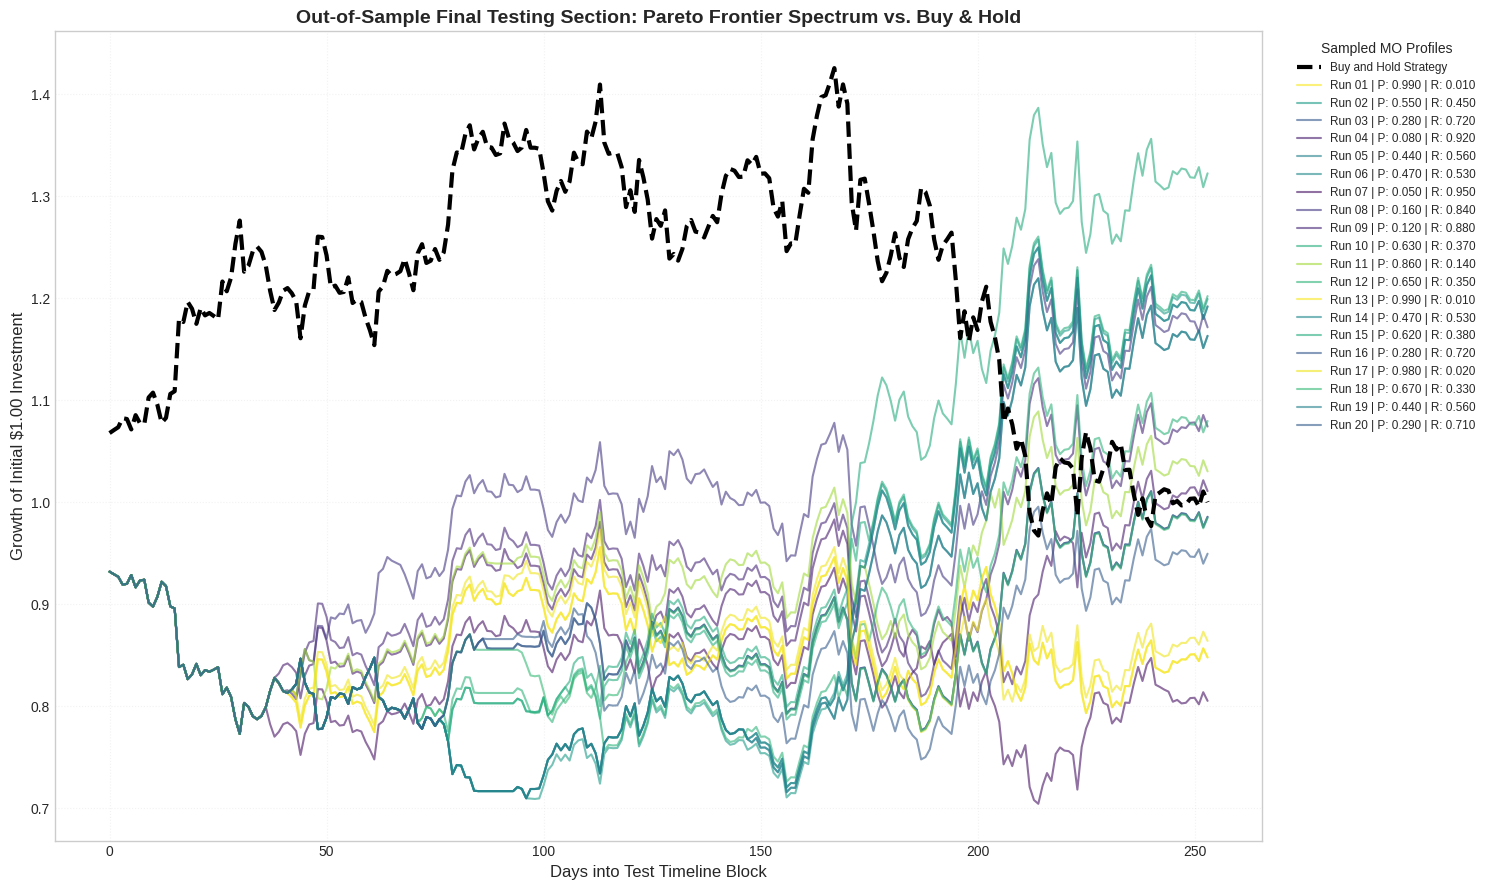


 QUANTITATIVE PARETO FRONTIER SPECTRUM PERFORMANCE REPORT 
           Strategy W_Profit W_Risk Net Profit Ann. Return  Max DD Sharpe Sortino Profit Factor
Buy & Hold Baseline        -      -     -0.01%      -0.01% -32.15%   0.15    0.22          1.03
     Unified Run 01     0.99   0.01    -15.23%     -15.12% -17.07%  -0.40   -0.55          0.93
     Unified Run 02     0.55   0.45     19.91%      19.74% -23.91%   0.76    1.07          1.14
     Unified Run 03     0.28   0.72     -1.44%      -1.43% -17.07%   0.10    0.13          1.02
     Unified Run 04     0.08   0.92      1.08%       1.07% -17.07%   0.19    0.26          1.03
     Unified Run 05     0.44   0.56     16.30%      16.16% -23.84%   0.65    0.94          1.12
     Unified Run 06     0.47   0.53     19.18%      19.02% -23.84%   0.74    1.05          1.14
     Unified Run 07     0.05   0.95    -19.48%     -19.35% -24.73%  -0.57   -0.77          0.91
     Unified Run 08     0.16   0.84     17.14%      16.99% -17.56%   0.68   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# 1. LOAD THE ABSOLUTE BEST VALIDATION WEIGHTS
# =====================================================================
print("Loading optimized checkpoint 'best_agent.pt' for final testing...")
agent.load_state_dict(torch.load("best_agent.pt", map_location=device))
agent.eval()  # Freeze network structures completely

# Pull the clean testing dimensions from your pre-calculated test split
test_features = rl_test_features
test_prices = unified_close_test
total_test_steps = len(test_features) - 1  # Number of forward daily return chunks

# =====================================================================
# 2. COMPUTE PURE BUY & HOLD BENCHMARK FOR THIS SLICE
# =====================================================================
bh_returns = []
for i in range(total_test_steps):
    current_price = test_prices[i]
    next_price = test_prices[i + 1]
    bh_returns.append((next_price - current_price) / current_price)

bh_returns = np.array(bh_returns)
bh_equity = np.exp(np.log1p(bh_returns).cumsum())

# Setup the canvas
plt.figure(figsize=(15, 9))
plt.plot(bh_equity, label="Buy and Hold Strategy", color='black', linestyle='--', linewidth=3, zorder=5)

# Metrics tracking array
summary_table = []

def get_quantitative_metrics(name, returns, equity, w_profit=None, w_risk=None):
    """Computes academic financial metrics from daily returns and equity paths."""
    returns = np.array(returns)
    equity = np.array(equity)

    # 1. Absolute Growth
    tot_ret = (equity[-1] - 1.0) * 100

    # 2. Annualized Geometric Growth (Assumes daily bar steps scaled to a 252 trading day year)
    ann_ret = ((equity[-1]) ** (252.0 / len(equity)) - 1.0) * 100

    # 3. Peak-to-Trough Destructive Bounds (Max Drawdown)
    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / (running_max + 1e-8)
    max_dd = drawdowns.min() * 100

    # 4. Standard Sharpe vs. Downside Isolated Sortino Ratios
    mean_ret = np.mean(returns)
    std_dev = np.std(returns) + 1e-8
    sharpe = (mean_ret / std_dev) * np.sqrt(252)

    downside_returns = returns[returns < 0]
    downside_std = np.std(downside_returns) + 1e-8 if len(downside_returns) > 0 else 1e-8
    sortino = (mean_ret / downside_std) * np.sqrt(252)

    # 5. Profit Factor: Gross Gains over Gross Losses
    gross_profits = np.sum(returns[returns > 0])
    gross_losses = np.abs(np.sum(returns[returns < 0]))
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else float('inf')

    metric_row = {
        "Strategy": name,
        "W_Profit": f"{w_profit:.2f}" if w_profit is not None else "-",
        "W_Risk": f"{w_risk:.2f}" if w_risk is not None else "-",
        "Net Profit": f"{tot_ret:.2f}%",
        "Ann. Return": f"{ann_ret:.2f}%",
        "Max DD": f"{max_dd:.2f}%",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Profit Factor": f"{profit_factor:.2f}" if profit_factor != float('inf') else "Max"
    }
    return metric_row

# Register Benchmark Baseline Matrix
summary_table.append(get_quantitative_metrics("Buy & Hold Baseline", bh_returns, bh_equity))

# =====================================================================
# 3. BACKTEST 20 IDENTITY MATCHED PARETO PREFERENCE PROFILES
# =====================================================================
np.random.seed(SEED)  # For reproducible random profiles
print(f"Simulating 20 unique random preference profiles over {total_test_steps} out-of-sample testing periods...")

transaction_fee = 0.0005  # Matching your environment rules!

for run_idx in range(20):
    w_profit = np.random.uniform(0.0, 1.0)
    w_risk = 1.0 - w_profit
    test_preference = [w_profit, w_risk]

    agent_returns = []
    last_action = 1  # Start out in cash/flat

    for i in range(total_test_steps):
        state_vector = test_features[i]

        state_t = torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0).to(device)
        pref_t = torch.tensor(test_preference, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            action_probs, _ = agent(state_t, pref_t)
            action = torch.argmax(action_probs, dim=-1).item()  # Exploit the best choice

        position_multiplier = action - 1
        forward_day_return = bh_returns[i]
        allocated_return = position_multiplier * forward_day_return

        # flat <-> long/short costs one fee; long <-> short costs two fees.
        turnover = abs(int(action) - int(last_action))
        allocated_return -= transaction_fee * turnover

        agent_returns.append(allocated_return)
        last_action = action

    agent_equity = np.exp(np.log1p(agent_returns).cumsum())
    line_color = plt.cm.viridis(w_profit)

    # Plot curves
    plt.plot(agent_equity, color=line_color, alpha=0.6,
             label=f"Run {run_idx+1:02d} | P: {w_profit:.2f}0 | R: {w_risk:.2f}0")

    # Parse metrics for this run configuration
    run_name = f"Unified Run {run_idx+1:02d}"
    summary_table.append(get_quantitative_metrics(run_name, agent_returns, agent_equity, w_profit, w_risk))

# =====================================================================
# 4. FINALIZE VISUALIZATIONS
# =====================================================================
plt.title("Out-of-Sample Final Testing Section: Pareto Frontier Spectrum vs. Buy & Hold", fontsize=14, fontweight='bold')
plt.xlabel("Days into Test Timeline Block", fontsize=12)
plt.ylabel("Growth of Initial $1.00 Investment", fontsize=12)
plt.grid(True, alpha=0.25, linestyle=':')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5, title="Sampled MO Profiles", title_fontsize=10)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. PRINT COMPREHENSIVE STRATEGY SUMMARY TABLE
# =====================================================================
print("\n" + "="*95 + "\n QUANTITATIVE PARETO FRONTIER SPECTRUM PERFORMANCE REPORT \n" + "="*95)
df_metrics = pd.DataFrame(summary_table)
print(df_metrics.to_string(index=False))

Traditional Method for RL

In [34]:
# =====================================================================
# DENG ET AL. (2017) MULTI-HORIZON AND FUZZY REPRESENTATION PIPELINE
# =====================================================================

def build_deng_2017_features(df_raw_1min):
    """
    Constructs a 50-dimensional multi-horizon feature matrix from raw 1-minute close prices:
    - Trailing 45 minutes of 1-minute price changes (returns)
    - Momentum blocks for 3h, 5h, 1d, 3d, and 10d horizons
    """
    # Ensure raw close series is flattened and isolated
    close_series = df_raw_1min['Close'].squeeze()

    # Calculate base 1-minute price returns (z_t = p_t - p_{t-1})
    # Using percent changes keeps the values stationary for the fuzzy layer
    returns_1min = close_series.pct_change()

    df_deng = pd.DataFrame(index=df_raw_1min.index)

    # 1. Short-term microstructure window (Trailing 45 minutes)
    for lag in range(45):
        df_deng[f'Lag_{lag}'] = returns_1min.shift(lag)

    # 2. Multi-horizon momentum blocks (Assumes standard cryptocurrency 24/7 market trading minutes)
    # 3 hours = 180 min; 5 hours = 300 min; 1 day = 1440 min; 3 days = 4320 min; 10 days = 14400 min
    horizons = {
        'Momentum_3h': 180,
        'Momentum_5h': 300,
        'Momentum_1d': 1440,
        'Momentum_3d': 4320,
        'Momentum_10d': 14400
    }

    for name, minutes in horizons.items():
        # Long-term change relative to historical reference points
        df_deng[name] = (close_series - close_series.shift(minutes)) / (close_series.shift(minutes) + 1e-8)

    # Clean up initial lookahead/lag alignment gaps
    df_deng = df_deng.dropna()
    return df_deng.values

class DataDrivenFuzzyMembershipLayer(nn.Module):
    """
    Maps a 50-dimensional raw multi-horizon vector into an expanded R^150 space.
    Categorizes inputs into 3 data-driven Gaussian classes: Bullish, Bearish, and Flat.
    """
    def __init__(self, input_dim=50, classes_per_feature=3):
        super(DataDrivenFuzzyMembershipLayer, self).__init__()
        self.input_dim = input_dim
        self.classes_per_feature = classes_per_feature

        # Learnable mean clusters (m_i) and variance scaling coefficients (sigma_i^2)
        # Parameters will initialize automatically via optimization gradients or backprop
        self.means = nn.Parameter(torch.randn(1, input_dim, classes_per_feature))
        self.log_vars = nn.Parameter(torch.zeros(1, input_dim, classes_per_feature))

    def forward(self, x):
        # x shape: (Batch, 50)
        batch_size = x.size(0)

        # Unsqueeze to align dimensions for parallel operations: (Batch, 50, 1)
        x_expanded = x.unsqueeze(-1)

        # Compute differentiable continuous Gaussian membership degrees: exp( - (x - m)^2 / sigma^2 )
        variances = torch.exp(self.log_vars) + 1e-8
        num = -1.0 * torch.pow(x_expanded - self.means, 2)
        fuzzy_degrees = torch.exp(num / variances)  # Shape: (Batch, 50, 3)

        # Flatten the spatial dimension into a clean feature space of R^150
        return fuzzy_degrees.view(batch_size, -1)

In [35]:
# =====================================================================
# 1. DEFINE TRADITIONAL STATIC SINGLE-OBJECTIVE MLP ARCHITECTURE (WITH FUZZY LAYER)
# =====================================================================
class TraditionalSingleObjectiveMLP(nn.Module):
    def __init__(self, raw_input_dim=50, classes_per_feature=3, action_dim=3):
        super(TraditionalSingleObjectiveMLP, self).__init__()

        # Deng et al. (2017) Data-driven fuzzy membership layer mapping R^50 -> R^150
        self.fuzzy_layer = DataDrivenFuzzyMembershipLayer(input_dim=raw_input_dim, classes_per_feature=classes_per_feature)
        fuzzified_dim = raw_input_dim * classes_per_feature  # 50 * 3 = 150

        # Deep Neural Network (DNN) feature processing stack
        self.feature_layer = nn.Sequential(
            nn.Linear(fuzzified_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.actor_head = nn.Sequential(
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic_head = nn.Linear(64, 1)

    def forward(self, x):
        fuzzified_x = self.fuzzy_layer(x)
        features = self.feature_layer(fuzzified_x)
        action_probs = self.actor_head(features)
        state_value = self.critic_head(features)
        return action_probs, state_value


# yfinance only provides hourly data for the last 730 days, not the full 5-year
# window needed. Instead we reuse the daily BTC data already downloaded in Cell 2
# (stored in `df` and `close_series`) and scale Deng's horizons to daily bars:
#   Trailing window : 45 daily returns     (Deng: 45 x 1-min bars)
#   Momentum_3h     : 1  day  (~8 sessions)(Deng: 3h)
#   Momentum_5h     : 1  day  (same bin)   (Deng: 5h)
#   Momentum_1d     : 1  day               (Deng: 1440 min)
#   Momentum_3d     : 3  days              (Deng: 4320 min)
#   Momentum_10d    : 10 days              (Deng: 14400 min)
# Note: 3h and 5h collapse to 1-day at daily resolution — this is an honest
# limitation stated in the paper since sub-daily data is unavailable over 5 years.

print("Building Deng et al. (2017) feature matrix on daily bars (finest available resolution)...")

returns_daily = close_series.pct_change()

df_deng = pd.DataFrame(index=close_series.index)

# 1. Trailing 45-day microstructure window (lags 0..44, all backward-looking)
for lag in range(45):
    df_deng[f'Lag_{lag}'] = returns_daily.shift(lag)

# 2. Multi-horizon momentum blocks scaled to daily bars
horizons = {
    'Momentum_3h':  1,   # sub-daily collapsed to 1 day at this resolution
    'Momentum_5h':  1,   # sub-daily collapsed to 1 day at this resolution
    'Momentum_1d':  1,
    'Momentum_3d':  3,
    'Momentum_10d': 10,
}
for col_name, n_days in horizons.items():
    df_deng[col_name] = (close_series - close_series.shift(n_days)) / (close_series.shift(n_days) + 1e-8)

# Drop NaN rows from the 45-day lag
df_deng = df_deng.dropna()
print(f"Deng feature matrix shape: {df_deng.shape}")  # Should be (N, 50)

# =====================================================================
# 3. ALIGN CLOSE PRICES AND SPLIT CHRONOLOGICALLY 70/15/15
# =====================================================================
deng_close_aligned = close_series.reindex(df_deng.index).values
deng_matrix = df_deng.values
deng_total  = len(deng_matrix)

# Rename to match rest of cell
deng_close_hourly = deng_close_aligned

deng_val_size   = int(deng_total * 0.15)
deng_test_size  = int(deng_total * 0.15)
deng_train_size = deng_total - (deng_val_size + deng_test_size)

deng_train_raw = deng_matrix[:deng_train_size]
deng_val_raw   = deng_matrix[deng_train_size : deng_train_size + deng_val_size]
deng_test_raw  = deng_matrix[deng_train_size + deng_val_size:]

deng_close_train = deng_close_hourly[:deng_train_size]
deng_close_val   = deng_close_hourly[deng_train_size : deng_train_size + deng_val_size]
deng_close_test  = deng_close_hourly[deng_train_size + deng_val_size:]

# Scale using training stats only — no leakage into val/test
deng_scaler = StandardScaler()
deng_train_scaled = deng_scaler.fit_transform(deng_train_raw)
deng_val_scaled   = deng_scaler.transform(deng_val_raw)
deng_test_scaled  = deng_scaler.transform(deng_test_raw)

print(f"-> Deng Train : {deng_train_scaled.shape} | Hours: {len(deng_close_train)}")
print(f"-> Deng Val   : {deng_val_scaled.shape}   | Hours: {len(deng_close_val)}")
print(f"-> Deng Test  : {deng_test_scaled.shape}   | Hours: {len(deng_close_test)}")


# =====================================================================
# 4. INITIALIZE TRADITIONAL BASELINES WITH PROPER DENG ENVIRONMENTS
# =====================================================================
print("\nPhase 2: Initializing Traditional Baseline Agents using Deng et al. (2017) method...")

legacy_mlp_profit = TraditionalSingleObjectiveMLP(raw_input_dim=50, classes_per_feature=3, action_dim=3).to(device)
legacy_mlp_risk   = TraditionalSingleObjectiveMLP(raw_input_dim=50, classes_per_feature=3, action_dim=3).to(device)

env_mlp_p = MultiObjectiveTradingEnv(deng_train_scaled, deng_close_train)
env_mlp_r = MultiObjectiveTradingEnv(deng_train_scaled, deng_close_train)

env_mlp_p.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(50,), dtype=np.float32)
env_mlp_r.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(50,), dtype=np.float32)

opt_p = torch.optim.Adam(legacy_mlp_profit.parameters(), lr=3e-4)
opt_r = torch.optim.Adam(legacy_mlp_risk.parameters(), lr=3e-4)

legacy_epochs   = 1000
gamma_legacy    = 0.99
clip_eps_trad   = 0.2
ppo_epochs_trad = 4


# =====================================================================
# 5. TRAIN TRADITIONAL PROFIT BOT (Maximizes Returns Only)
# =====================================================================
legacy_mlp_profit.train()
print("\nTraining Traditional Profit Bot (Fuzzy MLP) -> Locked at 100% Profit Target...")

for epoch in range(legacy_epochs):
    state, _ = env_mlp_p.reset()
    env_mlp_p.w_profit   = 1.0
    env_mlp_p.w_drawdown = 0.0

    done = False
    mem_states, mem_actions, mem_logprobs, mem_rewards, mem_values, mem_dones = [], [], [], [], [], []

    while not done:
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            probs, val = legacy_mlp_profit(state_t)
            dist   = torch.distributions.Categorical(probs)
            action = dist.sample()
            lp     = dist.log_prob(action)

        next_state, reward, terminated, truncated, _ = env_mlp_p.step(action.item())
        done = terminated or truncated

        mem_states.append(state_t.squeeze(0))
        mem_actions.append(action)
        mem_logprobs.append(lp)
        mem_rewards.append(reward)
        mem_values.append(val.squeeze(0))
        mem_dones.append(done)
        state = next_state

    # Compute discounted returns
    returns_p, disc = [], 0
    for r, d in zip(reversed(mem_rewards), reversed(mem_dones)):
        if d:
            disc = 0
        disc = r + gamma_legacy * disc
        returns_p.insert(0, disc)

    b_states   = torch.stack(mem_states)
    b_actions  = torch.stack(mem_actions)
    b_logprobs = torch.stack(mem_logprobs)
    b_returns  = torch.tensor(returns_p, dtype=torch.float32).to(device)
    b_values   = torch.stack(mem_values).squeeze(-1)

    # PPO update
    for _ in range(ppo_epochs_trad):
        new_probs, new_vals = legacy_mlp_profit(b_states)
        new_vals = new_vals.squeeze(-1)
        new_dist = torch.distributions.Categorical(new_probs)
        new_lp   = new_dist.log_prob(b_actions)
        entropy  = new_dist.entropy().mean()

        adv = b_returns - b_values
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        ratios = torch.exp(new_lp - b_logprobs)
        surr1  = ratios * adv
        surr2  = torch.clamp(ratios, 1 - clip_eps_trad, 1 + clip_eps_trad) * adv

        loss_p = -torch.min(surr1, surr2).mean() \
                 + 0.5 * nn.MSELoss()(new_vals, b_returns) \
                 - 0.01 * entropy

        opt_p.zero_grad()
        loss_p.backward()
        opt_p.step()

    if (epoch + 1) % 100 == 0:
        print(f"  Profit Bot Epoch {epoch+1}/{legacy_epochs} | Reward: {sum(mem_rewards):.4f}")


# =====================================================================
# 6. TRAIN TRADITIONAL RISK BOT (Minimizes Downside Only)
# =====================================================================
legacy_mlp_risk.train()
print("\nTraining Traditional Risk Bot (Fuzzy MLP) -> Locked at 100% Risk-Aversion...")

for epoch in range(legacy_epochs):
    state, _ = env_mlp_r.reset()
    env_mlp_r.w_profit   = 0.0
    env_mlp_r.w_drawdown = 1.0

    done = False
    mem_states, mem_actions, mem_logprobs, mem_rewards, mem_values, mem_dones = [], [], [], [], [], []

    while not done:
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            probs, val = legacy_mlp_risk(state_t)
            dist   = torch.distributions.Categorical(probs)
            action = dist.sample()
            lp     = dist.log_prob(action)

        next_state, reward, terminated, truncated, _ = env_mlp_r.step(action.item())
        done = terminated or truncated

        mem_states.append(state_t.squeeze(0))
        mem_actions.append(action)
        mem_logprobs.append(lp)
        mem_rewards.append(reward)
        mem_values.append(val.squeeze(0))
        mem_dones.append(done)
        state = next_state

    # Compute discounted returns
    returns_r, disc = [], 0
    for r, d in zip(reversed(mem_rewards), reversed(mem_dones)):
        if d:
            disc = 0
        disc = r + gamma_legacy * disc
        returns_r.insert(0, disc)

    b_states   = torch.stack(mem_states)
    b_actions  = torch.stack(mem_actions)
    b_logprobs = torch.stack(mem_logprobs)
    b_returns  = torch.tensor(returns_r, dtype=torch.float32).to(device)
    b_values   = torch.stack(mem_values).squeeze(-1)

    # PPO update
    for _ in range(ppo_epochs_trad):
        new_probs, new_vals = legacy_mlp_risk(b_states)
        new_vals = new_vals.squeeze(-1)
        new_dist = torch.distributions.Categorical(new_probs)
        new_lp   = new_dist.log_prob(b_actions)
        entropy  = new_dist.entropy().mean()

        adv = b_returns - b_values
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        ratios = torch.exp(new_lp - b_logprobs)
        surr1  = ratios * adv
        surr2  = torch.clamp(ratios, 1 - clip_eps_trad, 1 + clip_eps_trad) * adv

        loss_r = -torch.min(surr1, surr2).mean() \
                 + 0.5 * nn.MSELoss()(new_vals, b_returns) \
                 - 0.01 * entropy

        opt_r.zero_grad()
        loss_r.backward()
        opt_r.step()

    if (epoch + 1) % 100 == 0:
        print(f"  Risk Bot Epoch {epoch+1}/{legacy_epochs} | Reward: {sum(mem_rewards):.4f}")

print("\nLegacy single-objective fuzzy systems trained successfully!")

Building Deng et al. (2017) feature matrix on daily bars (finest available resolution)...
Deng feature matrix shape: (1781, 50)
-> Deng Train : (1247, 50) | Hours: 1247
-> Deng Val   : (267, 50)   | Hours: 267
-> Deng Test  : (267, 50)   | Hours: 267

Phase 2: Initializing Traditional Baseline Agents using Deng et al. (2017) method...

Training Traditional Profit Bot (Fuzzy MLP) -> Locked at 100% Profit Target...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Profit Bot Epoch 100/1000 | Reward: -2.0312
  Profit Bot Epoch 200/1000 | Reward: -0.7933
  Profit Bot Epoch 300/1000 | Reward: -1.3904
  Profit Bot Epoch 400/1000 | Reward: 0.0764
  Profit Bot Epoch 500/1000 | Reward: 0.7546
  Profit Bot Epoch 600/1000 | Reward: 0.7354
  Profit Bot Epoch 700/1000 | Reward: -0.9138
  Profit Bot Epoch 800/1000 | Reward: 0.1902
  Profit Bot Epoch 900/1000 | Reward: -1.6612
  Profit Bot Epoch 1000/1000 | Reward: -1.4497

Training Traditional Risk Bot (Fuzzy MLP) -> Locked at 100% Risk-Aversion...
  Risk Bot Epoch 100/1000 | Reward: -9.6355
  Risk Bot Epoch 200/1000 | Reward: -9.3241
  Risk Bot Epoch 300/1000 | Reward: -7.5590
  Risk Bot Epoch 400/1000 | Reward: -8.9103
  Risk Bot Epoch 500/1000 | Reward: -9.7080
  Risk Bot Epoch 600/1000 | Reward: -9.2502
  Risk Bot Epoch 700/1000 | Reward: -9.0222
  Risk Bot Epoch 800/1000 | Reward: -9.0596
  Risk Bot Epoch 900/1000 | Reward: -9.8489
  Risk Bot Epoch 1000/1000 | Reward: -8.8254

Legacy single-objective

Simulating 20 unique traditional ensemble profiles over 266 out-of-sample periods...


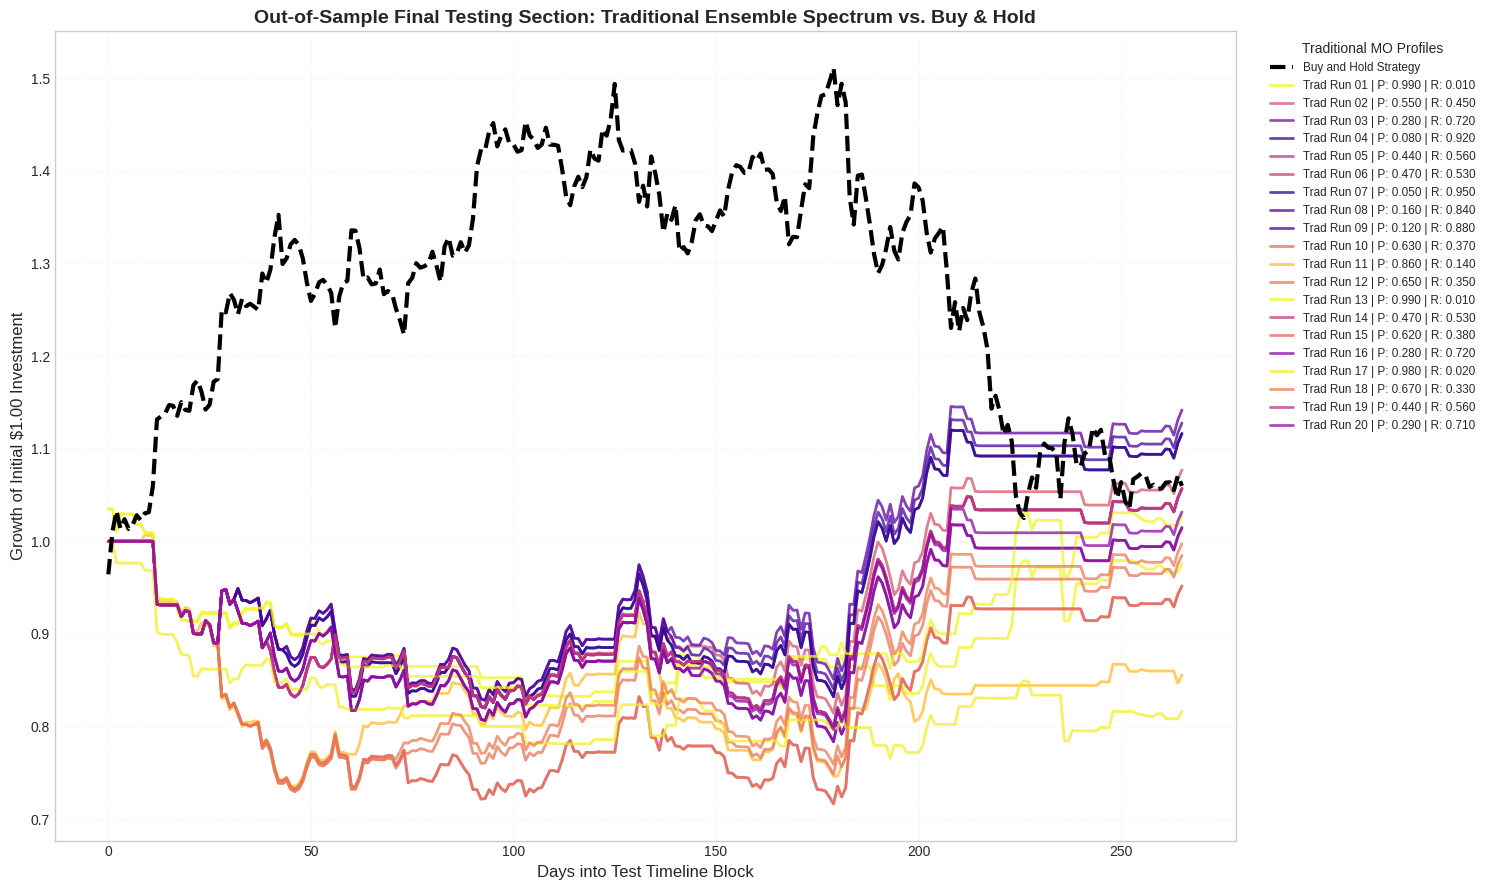


 QUANTITATIVE PARETO FRONTIER SPECTRUM PERFORMANCE REPORT (TRADITIONAL METHOD) 
           Strategy W_Profit W_Risk Net Profit Ann. Return  Max DD Sharpe Sortino Profit Factor
Buy & Hold Baseline        -      -      5.98%       5.65% -32.15%   0.33    0.50          1.06
        Trad Run 01     0.99   0.01     -2.38%      -2.26% -19.97%  -0.05   -0.05          0.98
        Trad Run 02     0.55   0.45      7.69%       7.27% -18.56%   0.42    0.53          1.10
        Trad Run 03     0.28   0.72      1.47%       1.39% -21.63%   0.17    0.22          1.04
        Trad Run 04     0.08   0.92     11.63%      10.99% -17.99%   0.57    0.72          1.13
        Trad Run 05     0.44   0.56      5.69%       5.38% -20.08%   0.34    0.44          1.08
        Trad Run 06     0.47   0.53      5.69%       5.38% -20.08%   0.34    0.44          1.08
        Trad Run 07     0.05   0.95     11.63%      10.99% -17.99%   0.57    0.72          1.13
        Trad Run 08     0.16   0.84     14.17%      13.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [36]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Define trading simulation parameters matching the environments
transaction_fee = 0.0005
test_prices = deng_close_test                  # Aligned close prices for the Deng test slice
test_features_source = deng_test_scaled        # True 50-dim Deng features — no padding needed
total_test_steps = len(test_features_source) - 1

# Setup the visualization canvas
plt.figure(figsize=(15, 9))

# =====================================================================
# 1. EVALUATE BENCHMARK: BUY & HOLD
# =====================================================================
bh_returns = []
for i in range(total_test_steps):
    current_price = test_prices[i]
    next_price = test_prices[i + 1]
    bh_returns.append((next_price - current_price) / current_price)

bh_returns = np.array(bh_returns)
bh_equity = np.exp(np.log1p(bh_returns).cumsum())

plt.plot(bh_equity, label="Buy and Hold Strategy", color='black', linestyle='--', linewidth=3, zorder=5)

# Metrics tracking structure
summary_table = []

def get_quantitative_metrics(name, returns, equity, w_profit=None, w_risk=None):
    """Computes academic financial metrics from daily returns and equity paths."""
    returns = np.array(returns)
    equity = np.array(equity)

    # 1. Absolute Growth
    tot_ret = (equity[-1] - 1.0) * 100

    # 2. Annualized Geometric Growth (Assumes daily steps scaled to a 252 trading day year)
    ann_ret = ((equity[-1]) ** (252.0 / len(equity)) - 1.0) * 100

    # 3. Peak-to-Trough Destructive Bounds (Max Drawdown)
    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / (running_max + 1e-8)
    max_dd = drawdowns.min() * 100

    # 4. Standard Sharpe vs. Downside Isolated Sortino Ratios
    mean_ret = np.mean(returns)
    std_dev = np.std(returns) + 1e-8
    sharpe = (mean_ret / std_dev) * np.sqrt(252)

    downside_returns = returns[returns < 0]
    downside_std = np.std(downside_returns) + 1e-8 if len(downside_returns) > 0 else 1e-8
    sortino = (mean_ret / downside_std) * np.sqrt(252)

    # 5. Profit Factor: Gross Gains over Gross Losses
    gross_profits = np.sum(returns[returns > 0])
    gross_losses = np.abs(np.sum(returns[returns < 0]))
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else float('inf')

    metric_row = {
        "Strategy": name,
        "W_Profit": f"{w_profit:.2f}" if w_profit is not None else "-",
        "W_Risk": f"{w_risk:.2f}" if w_risk is not None else "-",
        "Net Profit": f"{tot_ret:.2f}%",
        "Ann. Return": f"{ann_ret:.2f}%",
        "Max DD": f"{max_dd:.2f}%",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Profit Factor": f"{profit_factor:.2f}" if profit_factor != float('inf') else "Max"
    }
    return metric_row

# Register Benchmark Baseline Matrix
summary_table.append(get_quantitative_metrics("Buy & Hold Baseline", bh_returns, bh_equity))

# =====================================================================
# 2. BACKTEST 20 IDENTITY MATCHED TRADITIONAL PROFILE WEIGHTS
# =====================================================================
np.random.seed(SEED)  # CRUCIAL: Synchronizes perfectly with your original agent seed state
print(f"Simulating 20 unique traditional ensemble profiles over {total_test_steps} out-of-sample periods...")

legacy_mlp_profit.eval()
legacy_mlp_risk.eval()

for run_idx in range(20):
    w_profit = np.random.uniform(0.0, 1.0)
    w_risk = 1.0 - w_profit

    trad_returns = []
    last_action = 1  # Start out in cash/flat

    for i in range(total_test_steps):
        state = test_features_source[i]  # Already 50-dim — no padding needed

        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            # Interrogate both single-objective legacy fuzzy models safely
            prob_p, _ = legacy_mlp_profit(state_t)
            prob_r, _ = legacy_mlp_risk(state_t)

            # Linearly blend their distribution vectors using the exact preference pair
            blended_probs = (w_profit * prob_p) + (w_risk * prob_r)
            action = torch.argmax(blended_probs, dim=-1).item()

        position_multiplier = action - 1
        forward_day_return = bh_returns[i]
        allocated_return = position_multiplier * forward_day_return

        # flat <-> long/short costs one fee; long <-> short costs two fees.
        turnover = abs(int(action) - int(last_action))
        allocated_return -= transaction_fee * turnover

        trad_returns.append(allocated_return)
        last_action = action

    trad_equity = np.exp(np.log1p(trad_returns).cumsum())
    line_color = plt.cm.plasma(w_profit)

    # Plot curves using identical label formatting as your master block
    plt.plot(trad_equity, color=line_color, alpha=0.75, linestyle='-', linewidth=2,
             label=f"Trad Run {run_idx+1:02d} | P: {w_profit:.2f}0 | R: {w_risk:.2f}0")

    # Parse comprehensive metrics for every individual run profile configuration
    run_name = f"Trad Run {run_idx+1:02d}"
    summary_table.append(get_quantitative_metrics(run_name, trad_returns, trad_equity, w_profit, w_risk))

# =====================================================================
# 3. FINALIZE VISUALIZATIONS
# =====================================================================
plt.title("Out-of-Sample Final Testing Section: Traditional Ensemble Spectrum vs. Buy & Hold", fontsize=14, fontweight='bold')
plt.xlabel("Days into Test Timeline Block", fontsize=12)
plt.ylabel("Growth of Initial $1.00 Investment", fontsize=12)
plt.grid(True, alpha=0.25, linestyle=':')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5, title="Traditional MO Profiles", title_fontsize=10)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. PRINT ADVANCED STRATEGY PERFORMANCE ANALYSIS REPORT
# =====================================================================
print("\n" + "="*95 + "\n QUANTITATIVE PARETO FRONTIER SPECTRUM PERFORMANCE REPORT (TRADITIONAL METHOD) \n" + "="*95)
df_metrics = pd.DataFrame(summary_table)
print(df_metrics.to_string(index=False))